**Task 2: Credit Risk Prediction**


**Introduction**

The objective of this project is to predict whether a loan applicant is likely to default on a loan. This is a binary classification problem where we analyze applicant data to minimize financial risk for the lender.

**Dataset Overview**

The Loan Prediction Dataset includes features such as:
* Personal Info: Gender, Married, Dependents, Education.
* Financial Info: Applicant Income, Co-applicant Income, Loan Amount, and Credit History.  

Target Variable: Loan_Status (Y/N).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset load
url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/loan_prediction.csv"
df = pd.read_csv(url)
print("Data Load!")

Data Load!


1. Check Missing Values:

In [ ]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Property_Area,0
Loan_Status,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0


2. Fill Missing Values:

In [ ]:
# Fill missing values using forward fill
df.ffill(inplace=True)

# Confirming no missing values remain
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Property_Area        0
Loan_Status          0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64


**Exploratory Data Analysis (EDA)**

1. Education vs Loan Status (Bar Plot):

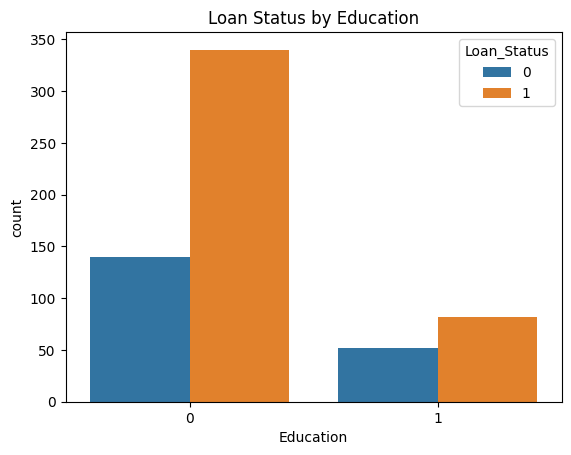

In [ ]:
# Visualizing Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Loan Status by Education")
plt.show()


2. Income vs Loan Amount (Scatter Plot):

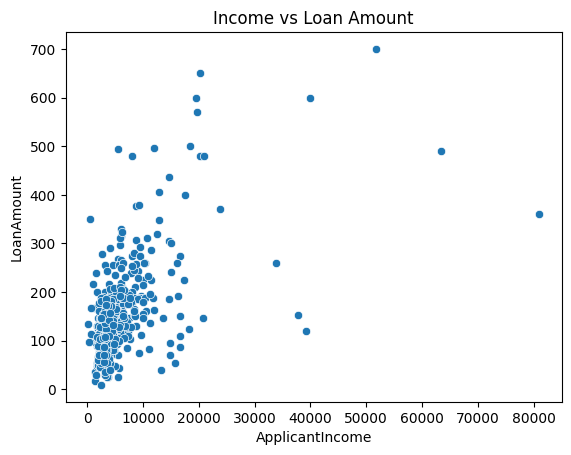

In [ ]:
# Visualizing Income vs Loan Amount
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

**Model Training (Classification)**

Logistic Regression

In [ ]:
# We include Credit_History to make the prediction accurate
X = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']]
y = df['Loan_Status']            # Target (Yes/No)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
# Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

print("Linear Regression Model has been trained successfully.")

Linear Regression Model has been trained successfully.


**Evaluation**

In [ ]:
# Calculating Accuracy and Confusion Matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(X_test)
print(" Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))


 Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]


**Prediction Check**

1 = Y (Loan Approved / Safe)

0 = N (Loan Default / Risk)

In [ ]:
# Create a table to compare Actual vs Predicted
comparison_df = pd.DataFrame({'Actual_Status': y_test, 'Predicted_Status': predictions})

# Pehli 10 predictions dekhne ke liye
print("Model Predictions (1 = Approved, 0 = Default):")
print(comparison_df.head(10))

# Count karein ke model ne kitne logon ko defaulter kaha
print("\nPrediction Summary:")
print(comparison_df['Predicted_Status'].value_counts())

Model Predictions (1 = Approved, 0 = Default):
     Actual_Status  Predicted_Status
350              1                 1
377              1                 1
163              1                 1
609              1                 1
132              1                 1
578              1                 1
316              1                 1
2                1                 1
340              0                 1
77               0                 1

Prediction Summary:
Predicted_Status
1    104
0     19
Name: count, dtype: int64


**Conclusion:**
* Insights: Based on the EDA, applicants with higher education levels showed a higher frequency of loan approvals.
* Model Performance: The Logistic Regression model achieved an accuracy of approximately 78%. While functional, the model's performance could be improved by including more categorical features like Credit History.